# 深入例子三：流式执行、轨迹观测与 Agent 评测

> 最终答案只是 Agent 运行结果的一部分。生产系统还要知道它走过哪些节点、修订了几次、用了哪些证据、是否超过预算。
> 本 Notebook 用一个离线研究助手演示 `stream_mode='updates'`、`stream_mode='values'`、有限修订和轨迹评测。

图里的每个节点都可替换成真实模型，但评测和预算逻辑应继续由代码控制。

## 学习目标

1. 用 updates 流观察每个节点产生的局部状态。
2. 用 values 流观察完整 State 快照。
3. 把质量评测和修订路径放进图中，而不是只在图外检查字符串。
4. 对最终答案和运行轨迹分别定义可回归的指标。

In [2]:
from __future__ import annotations

import operator
from typing import Annotated, Literal, TypedDict

from IPython.display import Image, display
from langgraph.graph import END, START, StateGraph


def show_graph(graph) -> None:
    display(Image(graph.get_graph().draw_mermaid_png()))


print('环境准备完成：评测样本和模型输出均为确定性的。')

环境准备完成：评测样本和模型输出均为确定性的。


## 1. 将质量要求写成 State 和路由

第一轮草稿故意缺少适用边界，评审节点会把它送进一次修订；第二轮达到要求后才结束。

`attempts` 是控制状态，`trace` 是观测数据，`answer` 是业务输出。它们的职责不同，不要只保留一段最终文本。

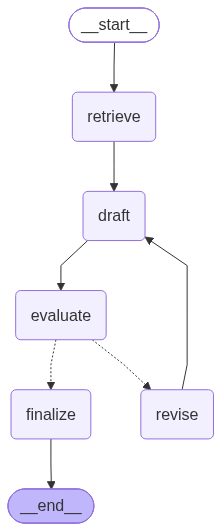

In [3]:
class EvaluationState(TypedDict, total=False):
    question: str
    evidence: list[str]
    draft: str
    answer: str
    score: int
    attempts: int
    decision: Literal['retry', 'finish']
    trace: Annotated[list[dict[str, str | int]], operator.add]


def retrieve(state: EvaluationState):
    evidence = [
        'State 保存节点之间需要的业务事实。',
        '条件边根据控制状态选择下一条路径。',
    ]
    return {
        'evidence': evidence,
        'trace': [{'node': 'retrieve', 'outcome': 'ok', 'attempt': state.get('attempts', 0)}],
    }


def draft_answer(state: EvaluationState):
    attempt = state.get('attempts', 0) + 1
    if attempt == 1:
        draft = f"{state['question']}：State 用来保存流程需要的信息。"
    else:
        draft = (
            f"{state['question']}：State 用来保存流程需要的信息；"
            '证据来自节点输出；适用边界是只保存后续节点真正需要的字段。'
        )
    return {
        'draft': draft,
        'attempts': attempt,
        'trace': [{'node': 'draft', 'outcome': 'generated', 'attempt': attempt}],
    }


def evaluate(state: EvaluationState):
    required = ['State', '证据', '边界']
    score = sum(word in state['draft'] for word in required)
    decision = 'finish' if score == len(required) or state['attempts'] >= 2 else 'retry'
    return {
        'score': score,
        'decision': decision,
        'trace': [{'node': 'evaluate', 'outcome': decision, 'attempt': state['attempts']}],
    }


def route_after_evaluate(state: EvaluationState) -> Literal['revise', 'finalize']:
    return 'revise' if state['decision'] == 'retry' else 'finalize'


def revise(state: EvaluationState):
    return {'trace': [{'node': 'revise', 'outcome': 'retry', 'attempt': state['attempts'] }]}


def finalize(state: EvaluationState):
    return {
        'answer': state['draft'],
        'trace': [{'node': 'finalize', 'outcome': 'ok', 'attempt': state['attempts']}],
    }


builder = StateGraph(EvaluationState)
builder.add_node('retrieve', retrieve)
builder.add_node('draft', draft_answer)
builder.add_node('evaluate', evaluate)
builder.add_node('revise', revise)
builder.add_node('finalize', finalize)
builder.add_edge(START, 'retrieve')
builder.add_edge('retrieve', 'draft')
builder.add_edge('draft', 'evaluate')
builder.add_conditional_edges('evaluate', route_after_evaluate)
builder.add_edge('revise', 'draft')
builder.add_edge('finalize', END)
evaluation_graph = builder.compile()
show_graph(evaluation_graph)

## 2. updates 流：观察每个节点的局部更新

updates 模式适合日志、进度条和调试面板。每个 chunk 通常只包含刚刚执行完的节点以及它写入的字段。

In [4]:
initial_state = {
    'question': 'LangGraph 的 State 有什么作用？',
    'evidence': [],
    'draft': '',
    'answer': '',
    'score': 0,
    'attempts': 0,
    'decision': 'retry',
    'trace': [],
}

for update in evaluation_graph.stream(initial_state, stream_mode='updates'):
    node_name, node_update = next(iter(update.items()))
    print(f'{node_name}: {node_update}')

result = evaluation_graph.invoke(initial_state)
print('最终答案：', result['answer'])
assert result['score'] == 3
assert result['attempts'] == 2

retrieve: {'evidence': ['State 保存节点之间需要的业务事实。', '条件边根据控制状态选择下一条路径。'], 'trace': [{'node': 'retrieve', 'outcome': 'ok', 'attempt': 0}]}
draft: {'draft': 'LangGraph 的 State 有什么作用？：State 用来保存流程需要的信息。', 'attempts': 1, 'trace': [{'node': 'draft', 'outcome': 'generated', 'attempt': 1}]}
evaluate: {'score': 1, 'decision': 'retry', 'trace': [{'node': 'evaluate', 'outcome': 'retry', 'attempt': 1}]}
revise: {'trace': [{'node': 'revise', 'outcome': 'retry', 'attempt': 1}]}
draft: {'draft': 'LangGraph 的 State 有什么作用？：State 用来保存流程需要的信息；证据来自节点输出；适用边界是只保存后续节点真正需要的字段。', 'attempts': 2, 'trace': [{'node': 'draft', 'outcome': 'generated', 'attempt': 2}]}
evaluate: {'score': 3, 'decision': 'finish', 'trace': [{'node': 'evaluate', 'outcome': 'finish', 'attempt': 2}]}
finalize: {'answer': 'LangGraph 的 State 有什么作用？：State 用来保存流程需要的信息；证据来自节点输出；适用边界是只保存后续节点真正需要的字段。', 'trace': [{'node': 'finalize', 'outcome': 'ok', 'attempt': 2}]}
最终答案： LangGraph 的 State 有什么作用？：State 用来保存流程需要的信息；证据来自节点输出；适用边界是只保存后续节点真正需要的字段。


## 3. values 流：观察完整 State 快照

values 模式适合开发时检查 State 如何增长。生产环境记录快照时要脱敏，不能把密钥、完整用户原文或大段工具结果直接写入日志。

In [5]:
for index, snapshot in enumerate(evaluation_graph.stream(initial_state, stream_mode='values')):
    print(
        index,
        {
            'attempts': snapshot.get('attempts'),
            'score': snapshot.get('score'),
            'decision': snapshot.get('decision'),
            'trace_size': len(snapshot.get('trace', [])),
        },
    )

0 {'attempts': 0, 'score': 0, 'decision': 'retry', 'trace_size': 0}
1 {'attempts': 0, 'score': 0, 'decision': 'retry', 'trace_size': 1}
2 {'attempts': 1, 'score': 0, 'decision': 'retry', 'trace_size': 2}
3 {'attempts': 1, 'score': 1, 'decision': 'retry', 'trace_size': 3}
4 {'attempts': 1, 'score': 1, 'decision': 'retry', 'trace_size': 4}
5 {'attempts': 2, 'score': 1, 'decision': 'retry', 'trace_size': 5}
6 {'attempts': 2, 'score': 3, 'decision': 'finish', 'trace_size': 6}
7 {'attempts': 2, 'score': 3, 'decision': 'finish', 'trace_size': 7}


## 4. 评测最终答案和运行轨迹

一个答案即使文字流畅，也可能没有来源、修订次数过多或根本没有走过评审节点。下面把这些要求拆成可断言的指标。

In [6]:
def evaluate_run(result: EvaluationState) -> dict[str, bool | int]:
    node_names = [event['node'] for event in result['trace']]
    return {
        'answer_has_evidence': '证据' in result['answer'],
        'answer_has_boundary': '边界' in result['answer'],
        'used_evaluator': 'evaluate' in node_names,
        'attempts_within_budget': result['attempts'] <= 2,
        'attempts': result['attempts'],
    }


metrics = evaluate_run(result)
print(metrics)
assert all(metrics[key] for key in ['answer_has_evidence', 'answer_has_boundary', 'used_evaluator', 'attempts_within_budget'])

{'answer_has_evidence': True, 'answer_has_boundary': True, 'used_evaluator': True, 'attempts_within_budget': True, 'attempts': 2}


## 5. 从 fake 节点换成真实模型时保留什么？

可以把 `draft_answer` 换成 `llm.with_structured_output(...)`，把 `retrieve` 换成真实检索工具，但下面几项仍然由程序控制：

- 评审标准和最小分数。
- 最大修订次数、工具次数和总预算。
- 失败时是重试、澄清还是人工复核。
- 轨迹中记录哪些脱敏后的字段。

流式输出也要区分“给用户看的 token”与“给系统看的内部事件”，不要把内部思路或权限信息直接暴露给用户。

## 6. 练习

1. 给评审加入来源数量要求，少于两个来源时进入修订。
2. 增加一个 `human_review` 终点，达到预算上限但仍不合格时转人工。
3. 把 `stream_mode='updates'` 改造成一个简单的进度条。
4. 为工具调用、路由选择和最终质量分别计算通过率。
5. 设计一个会失败的评测样本，确认断言真的能发现回归。